# Tox21 x Mass Spec: Dataset Construction + Evaluation

Builds train/val/test splits, trains RF classifiers on compounds *without* spectra,
then evaluates both ground-truth MACCS and MS2MACCS-predicted MACCS on the held-out splits.

In [1]:
import numpy as np
import pandas as pd
import joblib

from rdkit import Chem
from rdkit.Chem import MACCSkeys, inchi as rdinchi

from matchms.importing import load_from_mgf

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import balanced_accuracy_score

from tqdm import tqdm

import sys
sys.path.append("../../")
sys.path.append("../../scripts")
from ms2maccs import MS2MACCS
from imblearn.combine import SMOTEENN
from sklearn.model_selection import train_test_split


## 1  Load raw data

In [2]:
tox21 = pd.read_csv("../raw_data/tox21.csv")
SPECTRAVERSE = "../raw_data/spectraverse_most_frags_processed.mgf"

VAL_MGF  = "../../ms2_data/val_specs_H_p_mode.mgf"
TEST_MGF = "../../ms2_data/test_specs_H_p_mode.mgf"

TOX_COLS = [
    "NR-AR", "NR-AR-LBD", "NR-AhR", "NR-Aromatase",
    "NR-ER", "NR-ER-LBD", "NR-PPAR-gamma",
    "SR-ARE", "SR-ATAD5", "SR-HSE", "SR-MMP", "SR-p53",
]

tox21.head()

,NR-AR,NR-AR-LBD,NR-AhR,NR-Aromatase,NR-ER,NR-ER-LBD,NR-PPAR-gamma,SR-ARE,SR-ATAD5,SR-HSE,SR-MMP,SR-p53,mol_id,smiles
0,0.0,0.0,1.0,NaN,NaN,0.0,0.0,1.0,0.0,0.0,0.0,0.0,TOX3021,CCOc1ccc2nc(S(N)(=O)=O)sc2c1
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,TOX3020,CCN1C(=O)NC(c2ccccc2)C1=O
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,TOX3024,CC[C@]1(O)CC[C@H]2[C@@H]3CCC4=CCCC[C@@H]4[C@H]...
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,TOX3027,CCCN(CC)C(CC)C(=O)Nc1c(C)cccc1C
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,TOX20800,CC(O)(P(=O)(O)O)P(=O)(O)O


## 2  Build InChIKey index for tox21

In [3]:
tox21["inchikey"] = [
    rdinchi.MolToInchiKey(Chem.MolFromSmiles(s)) if Chem.MolFromSmiles(s) is not None else np.nan
    for s in tqdm(tox21.smiles, desc="tox21 inchikeys")
]
tox21 = tox21.dropna(subset=["inchikey"])

tox21 inchikeys:  29%|█████████████████▏                                         | 2273/7831 [00:01<00:02, 1971.44it/s][08:45:31] Explicit valence for atom # 3 Al, 6, is greater than permitted
[08:45:31] Explicit valence for atom # 4 Al, 6, is greater than permitted
tox21 inchikeys:  57%|█████████████████████████████████▍                         | 4443/7831 [00:02<00:01, 2023.70it/s][08:45:33] Explicit valence for atom # 9 Al, 6, is greater than permitted
[08:45:33] Explicit valence for atom # 5 Al, 6, is greater than permitted
tox21 inchikeys: 100%|███████████████████████████████████████████████████████████| 7831/7831 [00:03<00:00, 1991.25it/s]


In [4]:
tox21 = tox21.set_index("mol_id")
inchikey_to_molid = {row.inchikey: mol_id for mol_id, row in tox21.iterrows()}

In [6]:
tox21.shape

(7823, 14)

## 3  Match Spectraverse spectra to tox21 compounds

**Fixes vs original:**
- Filter to positive ionmode *before* the tox21 match
- Skip non-matching spectra entirely (original appended all of them)
- Tag matched spectra with `mol_id` for later lookup
- `continue` in the original never broke out of the inner loop; now we use a dict lookup (O(1))
- Deduplication now guards against `mol_id=None` (original collapsed all non-matching specs into one slot)

In [7]:
unique_tox_spectra = []

for spec in tqdm(load_from_mgf(SPECTRAVERSE), desc="Spectraverse"):
    if spec.get("ionmode") != "positive":
        continue
    ik = spec.get("inchikey")
    mol_id = inchikey_to_molid.get(ik)   # None if not a tox21 compound
    if mol_id is None:
        continue                          # skip non-tox21 spectra entirely
    spec.set("mol_id", str(mol_id))
    unique_tox_spectra.append(spec)

print(f"Unique tox21 compounds:  {len(unique_tox_spectra)}")

Spectraverse: 44297it [00:32, 1360.06it/s]

Unique tox21 compounds:  2237


## 4  Identify train / val / test compounds

`tox21_withSpec` = compounds that appear in the pre-built val or test MGF files (held-out).  
`tox21_noSpec`   = everything else - used to train the RF classifiers.

In [8]:
val_specs  = list(load_from_mgf(VAL_MGF))
test_specs = list(load_from_mgf(TEST_MGF))

val_mol_ids  = {inchikey_to_molid[s.get("inchikey")]
                for s in val_specs  if s.get("inchikey") in inchikey_to_molid}
test_mol_ids = {inchikey_to_molid[s.get("inchikey")]
                for s in test_specs if s.get("inchikey") in inchikey_to_molid}
held_out_ids = val_mol_ids | test_mol_ids

tox21_withSpec = tox21[tox21.index.isin(held_out_ids)]
tox21_noSpec   = tox21[~tox21.index.isin(held_out_ids)]

print(f"With spectrum (held-out): {len(tox21_withSpec)}")
print(f"Without spectrum (train): {len(tox21_noSpec)}")

# Save for reference (fix: add .csv extension)
tox21_withSpec.to_csv("tox21_withSpec.csv")

With spectrum (held-out): 1738
Without spectrum (train): 6085


## 5  Compute MACCS keys for the training set

In [9]:
tox21_noSpec = tox21_noSpec.copy()
tox21_noSpec["maccs"] = [
    np.array(MACCSkeys.GenMACCSKeys(Chem.MolFromSmiles(s)))
    for s in tqdm(tox21_noSpec.smiles, desc="MACCS (train)")
]

MACCS (train): 100%|██████████████████████████████████████████████████████████████| 6085/6085 [00:08<00:00, 744.46it/s]


## 6  Train one Random Forest classifier per tox endpoint

In [10]:
models = {}
metrics = {}

for col in TOX_COLS:
    subset = tox21_noSpec.dropna(subset=[col])

    X = np.vstack(subset["maccs"].tolist())
    y = subset[col].astype(int).values

    # Train / validation split
    X_train, X_val, y_train, y_val = train_test_split(
        X,
        y,
        test_size=0.2,
        stratify=y,
        random_state=42,
    )

    # Apply SMOTEENN balancing
    smoteenn = SMOTEENN(random_state=42)
    X_resampled, y_resampled = smoteenn.fit_resample(X_train, y_train)

    # Train model
    rf = RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        n_jobs=-1,
        random_state=42,
        class_weight="balanced_subsample",
    )

    rf.fit(X_resampled, y_resampled)

    # Validation score
    y_pred = rf.predict(X_val)
    bal_acc = balanced_accuracy_score(y_val, y_pred)

    models[col] = rf
    metrics[col] = bal_acc

    print(
        f"{col:20s} | "
        f"Original: {len(y_train):5d} | "
        f"Balanced: {len(y_resampled):5d} | "
        f"Balanced Accuracy: {bal_acc:.3f}"
    )

# Persist models
joblib_names = {
    "NR-AR": "rf_nr_ar",
    "NR-AR-LBD": "rf_nr_ar_lbd",
    "NR-AhR": "rf_nr_ahr",
    "NR-Aromatase": "rf_nr_aromatase",
    "NR-ER": "rf_nr_er",
    "NR-ER-LBD": "rf_nr_er_lbd",
    "NR-PPAR-gamma": "rf_nr_ppar_gamma",
    "SR-ARE": "rf_sr_are",
    "SR-ATAD5": "rf_sr_atad5",
    "SR-HSE": "rf_nr_hse",
    "SR-MMP": "rf_nr_mmp",
    "SR-p53": "rf_nr_p53",
}

for col, name in joblib_names.items():
    joblib.dump(models[col], f"{name}.joblib")


NR-AR                | Original:  4476 | Balanced:  7666 | Balanced Accuracy: 0.812
NR-AR-LBD            | Original:  4163 | Balanced:  7412 | Balanced Accuracy: 0.810
NR-AhR               | Original:  4050 | Balanced:  6297 | Balanced Accuracy: 0.797
NR-Aromatase         | Original:  3600 | Balanced:  6068 | Balanced Accuracy: 0.667
NR-ER                | Original:  3836 | Balanced:  4862 | Balanced Accuracy: 0.624
NR-ER-LBD            | Original:  4295 | Balanced:  7110 | Balanced Accuracy: 0.718
NR-PPAR-gamma        | Original:  3977 | Balanced:  7098 | Balanced Accuracy: 0.599
SR-ARE               | Original:  3536 | Balanced:  4347 | Balanced Accuracy: 0.649
SR-ATAD5             | Original:  4354 | Balanced:  7658 | Balanced Accuracy: 0.659
SR-HSE               | Original:  3929 | Balanced:  6380 | Balanced Accuracy: 0.644
SR-MMP               | Original:  3609 | Balanced:  4937 | Balanced Accuracy: 0.768
SR-p53               | Original:  4180 | Balanced:  6845 | Balanced Accuracy

## 7  Load MS2MACCS model

In [11]:
m = MS2MACCS(
    "../../models/standard_model.pt",
    "../../fp_bit_maps/fp_bit_map_H_p_mode.pkl",
    "../../fp_bit_maps/fp_bit_map_H_n_mode.pkl",
    "cpu",  # replace with "cpu" if no GPU
)

## 8  Evaluation helper

For each split:
1. Extract ground-truth MACCS from the `smiles` field in each spectrum's metadata
2. Call `MS2MACCS.predict()` on the MGF to get predicted MACCS (binarised at 0.5)
3. Align tox21 labels to spectrum order via inchikey
4. Evaluate balanced accuracy for both MACCS sources per endpoint

In [12]:
def evaluate_split(mgf_path: str, specs: list, split_name: str):
    """Evaluate RF tox predictions on a pre-loaded spectrum list.

    Args:
        mgf_path: path to the MGF file (passed to MS2MACCS.predict)
        specs:    already-loaded list of matchms Spectrum objects
        split_name: label for printing
    """
    print(f"\n{split_name}: {len(specs)} spectra")

    # 1. Ground-truth MACCS from the SMILES stored inside each spectrum
    gt_maccs = np.vstack([
        np.array(MACCSkeys.GenMACCSKeys(Chem.MolFromSmiles(s.get("smiles"))))
        for s in specs
    ])

    # 2. MS2MACCS-predicted MACCS
    pred_maccs = (m.predict(mgf_path).to("cpu").numpy() > 0.5).astype(int)

    # 3. Tox labels aligned to spectrum order
    mol_ids    = [inchikey_to_molid.get(s.get("inchikey")) for s in specs]
    tox_labels = tox21.reindex(mol_ids)[TOX_COLS].values  # (n, 12), NaN where absent

    # 4. Binary tox vectors (replace NaN with 0, then convert to binary)
    binary_tox_labels = np.where(np.isnan(tox_labels), 0, tox_labels).astype(int)

    # 5. Balanced accuracy per endpoint
    results_gt, results_pred = {}, {}
    for i, col in enumerate(TOX_COLS):
        mask = ~np.isnan(tox_labels[:, i])
        if mask.sum() == 0:
            continue
        y = tox_labels[mask, i]
        results_gt[col]   = balanced_accuracy_score(y, models[col].predict(gt_maccs[mask]))
        results_pred[col] = balanced_accuracy_score(y, models[col].predict(pred_maccs[mask]))
        print(f"  {col:20s}  gt={results_gt[col]:.4f}  ms2maccs={results_pred[col]:.4f}")

    return results_gt, results_pred, gt_maccs, pred_maccs, binary_tox_labels

## 9  Run evaluation

In [13]:
val_gt,  val_pred, val_maccs_gt, val_maccs_pred, val_tox = evaluate_split(VAL_MGF,  val_specs,  "Validation")
test_gt, test_pred, test_maccs_gt, test_maccs_pred, test_tox = evaluate_split(TEST_MGF, test_specs, "Test")


Validation: 4409 spectra


Processing val_specs_H_p_mode.mgf: 4409it [00:09, 475.12it/s]
Prediction: 100%|██████████████████████████████████████████████████████████████████| 4409/4409 [01:41<00:00, 43.47it/s]


  NR-AR                 gt=0.5064  ms2maccs=0.4867
  NR-AR-LBD             gt=0.5424  ms2maccs=0.4945
  NR-AhR                gt=0.7615  ms2maccs=0.6378
  NR-Aromatase          gt=0.6098  ms2maccs=0.5073
  NR-ER                 gt=0.6069  ms2maccs=0.5422
  NR-ER-LBD             gt=0.6119  ms2maccs=0.5493
  NR-PPAR-gamma         gt=0.5306  ms2maccs=0.5410
  SR-ARE                gt=0.6377  ms2maccs=0.5406
  SR-ATAD5              gt=0.6837  ms2maccs=0.5982
  SR-HSE                gt=0.5701  ms2maccs=0.5191
  SR-MMP                gt=0.7432  ms2maccs=0.5859
  SR-p53                gt=0.6039  ms2maccs=0.5288

Test: 1484 spectra


Processing test_specs_H_p_mode.mgf: 1484it [00:03, 444.62it/s]
Prediction: 100%|██████████████████████████████████████████████████████████████████| 1484/1484 [00:35<00:00, 42.15it/s]


  NR-AR                 gt=0.4843  ms2maccs=0.4817
  NR-AR-LBD             gt=0.7384  ms2maccs=0.4870
  NR-AhR                gt=0.7522  ms2maccs=0.7154
  NR-Aromatase          gt=0.6113  ms2maccs=0.5328
  NR-ER                 gt=0.6891  ms2maccs=0.5824
  NR-ER-LBD             gt=0.6516  ms2maccs=0.5780
  NR-PPAR-gamma         gt=0.6570  ms2maccs=0.4754
  SR-ARE                gt=0.6278  ms2maccs=0.5993
  SR-ATAD5              gt=0.7414  ms2maccs=0.5500
  SR-HSE                gt=0.6332  ms2maccs=0.5528
  SR-MMP                gt=0.7808  ms2maccs=0.6776
  SR-p53                gt=0.6158  ms2maccs=0.5491


## 10  Summary table

In [14]:
summary = pd.DataFrame({
    "Val  - gt MACCS":   val_gt,
    "Val  - MS2MACCS":   val_pred,
    "Test - gt MACCS":   test_gt,
    "Test - MS2MACCS":   test_pred,
})
summary.index.name = "Endpoint"
summary.round(4)

,Val - gt MACCS,Val - MS2MACCS,Test - gt MACCS,Test - MS2MACCS
Endpoint,,,,
NR-AR,0.5064,0.4867,0.4843,0.4817
NR-AR-LBD,0.5424,0.4945,0.7384,0.4870
NR-AhR,0.7615,0.6378,0.7522,0.7154
NR-Aromatase,0.6098,0.5073,0.6113,0.5328
NR-ER,0.6069,0.5422,0.6891,0.5824
NR-ER-LBD,0.6119,0.5493,0.6516,0.5780
NR-PPAR-gamma,0.5306,0.5410,0.6570,0.4754
SR-ARE,0.6377,0.5406,0.6278,0.5993
SR-ATAD5,0.6837,0.5982,0.7414,0.5500


## 11 FP comparison

In [15]:
import matplotlib.pyplot as plt

In [16]:
def calc_tanimoto(fp1, fp2):
    set1 = set(fp1) if isinstance(fp1, (list, set)) else set(np.where(fp1)[0])
    set2 = set(fp2) if isinstance(fp2, (list, set)) else set(np.where(fp2)[0])

    intersection = len(set1 & set2)
    union = len(set1 | set2)

    return intersection / union if union != 0 else 0.0

In [19]:
def find_different_bits(fp1, fp2):
    """Return the indices of bits that differ between two binary fingerprints."""
    return np.where(fp1 != fp2)[0]


tanimotos_all_correct = []
tanimotos_all_wrong = []
for i in tqdm(range(12)):
    tanimotos_endpoint_correct = []
    tanimotos_endpoint_wrong = []
    count_wrong = 0
    count_correct = 0
    for gt, pred, tox in zip(val_maccs_gt, val_maccs_pred, val_tox):
        tox_pred_gt = models[TOX_COLS[i]].predict(gt.reshape(1, -1)) 
        tox_pred_ms2maccs = models[TOX_COLS[i]].predict(pred.reshape(1, -1))
    
        if tox_pred_gt != tox_pred_ms2maccs:
            # If predictions differ, find differing bits
            different_bits = find_different_bits(gt, pred)
            #print(f"Predictions differ. Different bits: {different_bits} Tanimoto: {calc_tanimoto(gt, pred)}")
            count_wrong += 1
            tanimoto = calc_tanimoto(gt, pred)
            tanimotos_endpoint_correct.append(tanimoto)
        else:
            # If predictions agree, just print Tanimoto
            #print(calc_tanimoto(gt, pred))
            count_correct += 1
            tanimoto = calc_tanimoto(gt, pred)
            tanimotos_endpoint_wrong.append(tanimoto)

    print(TOX_COLS[i], count_wrong, count_correct)
    tanimotos_all_correct.append(tanimotos_endpoint_correct)
    tanimotos_all_wrong.append(tanimotos_endpoint_wrong)

  8%|██████▋                                                                         | 1/12 [09:38<1:46:08, 578.99s/it]

NR-AR 418 3991


 17%|█████████████▎                                                                  | 2/12 [19:01<1:34:53, 569.36s/it]

NR-AR-LBD 229 4180


 25%|████████████████████                                                            | 3/12 [28:25<1:25:03, 567.05s/it]

...

SR-HSE 407 4002


 92%|████████████████████████████████████████████████████████████████████████▍      | 11/12 [1:45:22<09:29, 569.13s/it]

SR-MMP 1079 3330


100%|███████████████████████████████████████████████████████████████████████████████| 12/12 [1:54:46<00:00, 573.90s/it]

SR-p53 836 3573


(array([ 15.,  43., 105., 165., 154., 163., 122., 103.,  25.,  13.]),
 array([0.        , 0.09811321, 0.19622642, 0.29433962, 0.39245283,
        0.49056604, 0.58867925, 0.68679245, 0.78490566, 0.88301887,
        0.98113208]),
 <BarContainer object of 10 artists>)

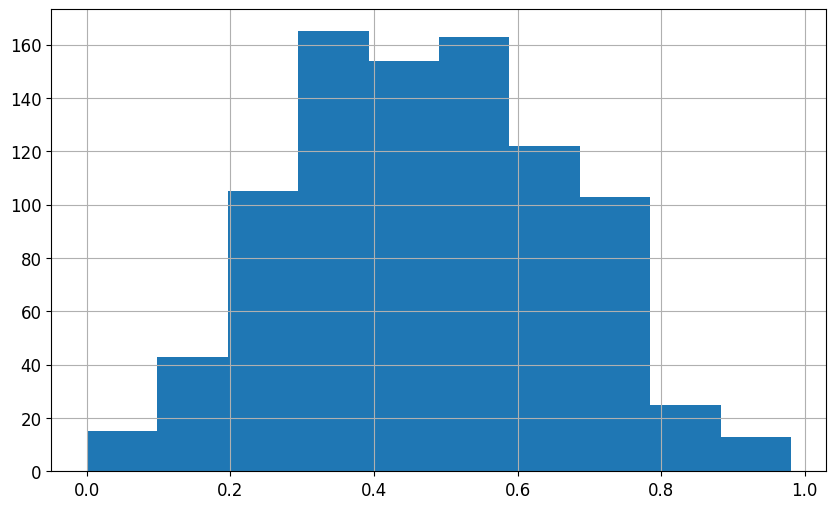

In [22]:
plt.hist(tanimotos_all_correct[4])

## Improved Visualization

The following plots compare Tanimoto similarities between:
- predictions where toxicity classification stayed consistent
- predictions where toxicity classification changed

The plots include:
- histogram overlays
- boxplots
- endpoint-level summary statistics


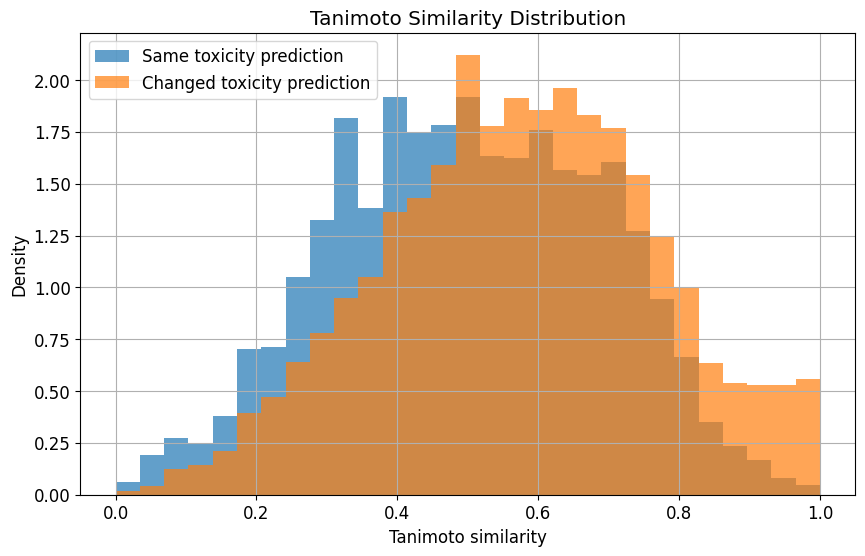

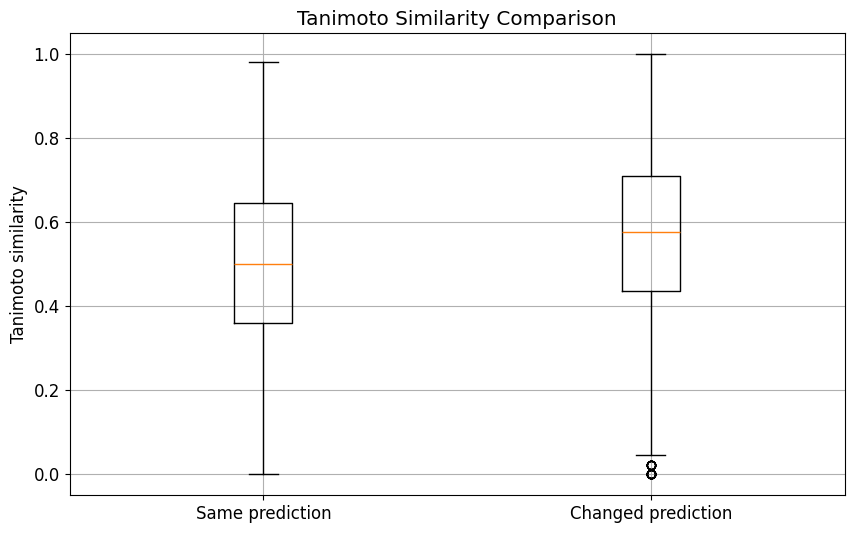

,Endpoint,Balanced Accuracy,Mean Similarity (same pred),Mean Similarity (changed pred)
0,NR-AR,0.811913,0.558224,0.562323
1,NR-AR-LBD,0.810418,0.550681,0.562551
2,NR-AhR,0.797437,0.488328,0.586611
3,NR-Aromatase,0.666570,0.498870,0.570718
4,NR-ER,0.624392,0.475039,0.584471
5,NR-ER-LBD,0.718004,0.552209,0.562894
6,NR-PPAR-gamma,0.599468,0.451104,0.568738
7,SR-ARE,0.648941,0.500684,0.586361
8,SR-ATAD5,0.659246,0.477040,0.573883
9,SR-HSE,0.644350,0.484544,0.569805


In [23]:
plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.grid": True,
    "font.size": 12,
})

# Flatten lists
correct_flat = np.concatenate([np.array(x) for x in tanimotos_all_correct if len(x) > 0])
wrong_flat = np.concatenate([np.array(x) for x in tanimotos_all_wrong if len(x) > 0])

# Histogram comparison
fig, ax = plt.subplots()

bins = np.linspace(0, 1, 30)

ax.hist(
    correct_flat,
    bins=bins,
    alpha=0.7,
    density=True,
    label="Same toxicity prediction",
)

ax.hist(
    wrong_flat,
    bins=bins,
    alpha=0.7,
    density=True,
    label="Changed toxicity prediction",
)

ax.set_xlabel("Tanimoto similarity")
ax.set_ylabel("Density")
ax.set_title("Tanimoto Similarity Distribution")
ax.legend()

plt.show()

# Boxplot comparison
fig, ax = plt.subplots()

ax.boxplot(
    [correct_flat, wrong_flat],
    tick_labels=["Same prediction", "Changed prediction"],
)

ax.set_ylabel("Tanimoto similarity")
ax.set_title("Tanimoto Similarity Comparison")

plt.show()

# Endpoint summary table
summary_df = pd.DataFrame({
    "Endpoint": TOX_COLS,
    "Balanced Accuracy": [metrics[c] for c in TOX_COLS],
    "Mean Similarity (same pred)": [
        np.mean(x) if len(x) > 0 else np.nan
        for x in tanimotos_all_correct
    ],
    "Mean Similarity (changed pred)": [
        np.mean(x) if len(x) > 0 else np.nan
        for x in tanimotos_all_wrong
    ],
})

summary_df


Processing NR-AR
Changed predictions: 418 / 4409
Processing NR-AR-LBD
Changed predictions: 229 / 4409
Processing NR-AhR
Changed predictions: 1107 / 4409
Processing NR-Aromatase
Changed predictions: 539 / 4409
Processing NR-ER
Changed predictions: 908 / 4409
Processing NR-ER-LBD
Changed predictions: 396 / 4409
Processing NR-PPAR-gamma
Changed predictions: 255 / 4409
Processing SR-ARE
Changed predictions: 1257 / 4409
Processing SR-ATAD5
Changed predictions: 544 / 4409
Processing SR-HSE
Changed predictions: 407 / 4409
Processing SR-MMP
Changed predictions: 1079 / 4409
Processing SR-p53
Changed predictions: 836 / 4409


,Endpoint,Bit,FreqChanged,FreqSame,Enrichment,Delta,Score
193,NR-AR-LBD,26,0.366812,0.026077,14.066243,0.340736,1.299622
217,NR-AR-LBD,50,0.379913,0.080383,4.726248,0.299530,0.671155
243,NR-AR-LBD,76,0.375546,0.091627,4.098613,0.283919,0.577814
26,NR-AR,26,0.210526,0.026309,8.001739,0.184217,0.552709
242,NR-AR-LBD,75,0.026201,0.202392,0.129460,-0.176191,0.519663
...,...,...,...,...,...,...,...
1953,SR-p53,116,0.163876,0.249650,0.656422,-0.085775,0.052091
1768,SR-MMP,98,0.325301,0.226126,1.438581,0.099175,0.052032
1320,SR-ARE,151,0.350835,0.248731,1.410500,0.102104,0.050665
1278,SR-ARE,109,0.312649,0.217322,1.438641,0.095327,0.050019


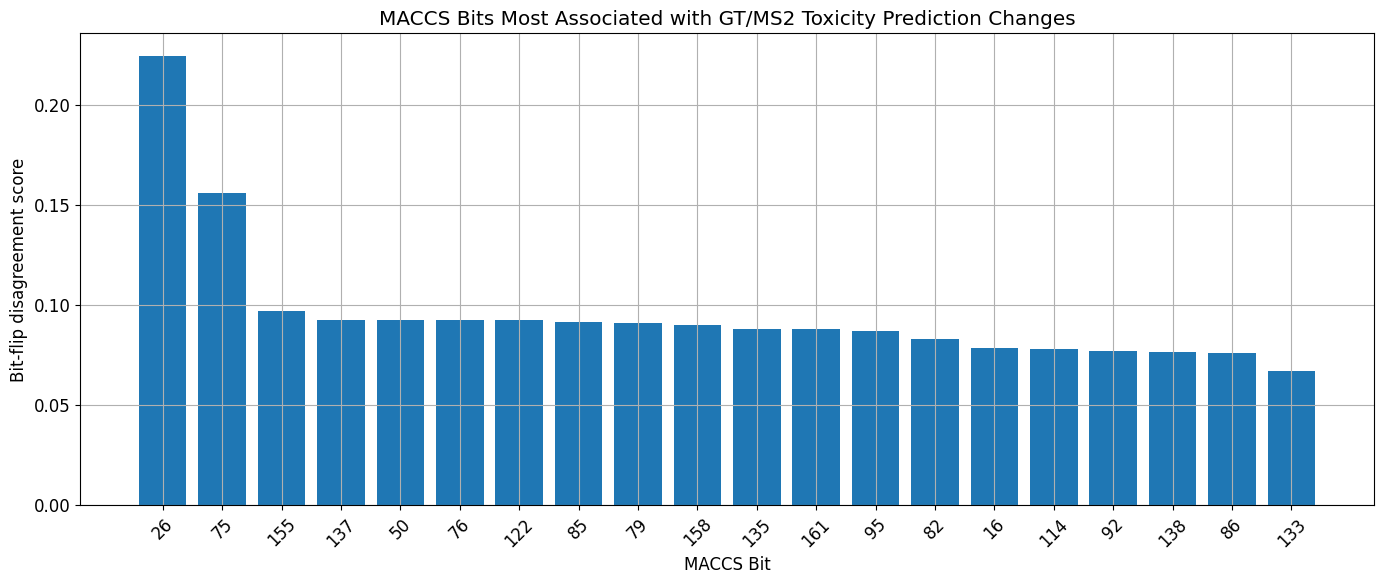

Endpoint,NR-AR,NR-AR-LBD,NR-AhR,NR-Aromatase,NR-ER,NR-ER-LBD,NR-PPAR-gamma,SR-ARE,SR-ATAD5,SR-HSE,SR-MMP,SR-p53
Bit,,,,,,,,,,,,
16,0.00,0.40,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
26,0.55,1.30,0.00,0.21,0.07,0.32,0.00,0.00,0.00,0.00,0.00,0.00
34,0.17,0.38,0.00,0.07,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
50,0.00,0.67,0.00,0.08,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
57,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.05,0.00,0.00,0.00,0.00
65,0.00,0.00,0.14,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
72,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.07
74,0.00,0.00,0.00,0.00,0.00,0.00,0.16,0.00,0.00,0.00,0.00,0.00
75,0.32,0.52,0.00,0.10,0.11,0.38,0.18,0.00,0.00,0.00,0.00,0.00


In [32]:
# ============================================================
# Analyze which MACCS bit flips cause GT/MS2 tox disagreements
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Assumptions
# ------------------------------------------------------------
# gt_maccs_all:
#     list/array of GT MACCS fingerprints
#
# ms2_maccs_all:
#     list/array of reconstructed MS2MACCS fingerprints
#
# models:
#     trained RF models dictionary
#
# TOX_COLS:
#     toxicity endpoints
#
# Shape:
#     fingerprints are binary vectors
# ------------------------------------------------------------

all_results = []

for tox_col in TOX_COLS:

    print(f"Processing {tox_col}")

    # --------------------------------------------------------
    # Prepare fingerprints
    # --------------------------------------------------------

    gt_X = np.vstack(val_maccs_gt)
    ms2_X = np.vstack(val_maccs_pred)

    rf = models[tox_col]

    # --------------------------------------------------------
    # Predict toxicity
    # --------------------------------------------------------

    gt_pred = rf.predict(gt_X)
    ms2_pred = rf.predict(ms2_X)

    # --------------------------------------------------------
    # Find molecules where tox prediction changed
    # --------------------------------------------------------

    tox_changed = (gt_pred != ms2_pred)

    print(
        f"Changed predictions: "
        f"{tox_changed.sum()} / {len(tox_changed)}"
    )

    # --------------------------------------------------------
    # Compute bit flips
    # --------------------------------------------------------

    # 1 if bit changed between GT and MS2
    bit_flip = np.abs(gt_X - ms2_X)

    # --------------------------------------------------------
    # Separate:
    #   tox changed
    #   tox unchanged
    # --------------------------------------------------------

    flip_changed = bit_flip[tox_changed]
    flip_same = bit_flip[~tox_changed]

    # --------------------------------------------------------
    # Compute frequencies
    # --------------------------------------------------------

    freq_changed = flip_changed.mean(axis=0)
    freq_same = flip_same.mean(axis=0)

    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------

    enrichment = (
        (freq_changed + 1e-6)
        / (freq_same + 1e-6)
    )

    delta = freq_changed - freq_same

    score = delta * np.log2(enrichment)

    # --------------------------------------------------------
    # Store results
    # --------------------------------------------------------

    for bit_idx in range(gt_X.shape[1]):

        all_results.append({
            "Endpoint": tox_col,
            "Bit": bit_idx,
            "FreqChanged": freq_changed[bit_idx],
            "FreqSame": freq_same[bit_idx],
            "Enrichment": enrichment[bit_idx],
            "Delta": delta[bit_idx],
            "Score": score[bit_idx],
        })

# ============================================================
# Create dataframe
# ============================================================

results_df = pd.DataFrame(all_results)

# Remove uninformative bits
results_df = results_df[
    results_df["FreqChanged"] > 0.01
]

# ============================================================
# Top bits per endpoint
# ============================================================

top_bits = (
    results_df
    .sort_values("Score", ascending=False)
    .groupby("Endpoint")
    .head(10)
)

display(top_bits)

# ============================================================
# Global top problematic bits
# ============================================================

global_scores = (
    results_df
    .groupby("Bit")["Score"]
    .mean()
    .sort_values(ascending=False)
)

top20 = global_scores.head(20)

# ============================================================
# Plot
# ============================================================

fig, ax = plt.subplots(figsize=(14, 6))

ax.bar(
    top20.index.astype(str),
    top20.values,
)

ax.set_xlabel("MACCS Bit")
ax.set_ylabel("Bit-flip disagreement score")
ax.set_title(
    "MACCS Bits Most Associated with GT/MS2 "
    "Toxicity Prediction Changes"
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ============================================================
# Heatmap-style table
# ============================================================

pivot = (
    top_bits
    .pivot_table(
        index="Bit",
        columns="Endpoint",
        values="Score"
    )
)

display(
    pivot.fillna(0).round(2)
)

In [35]:
global_scores.mean()

np.float64(0.034436947184001816)

In [41]:
indices = []
scores = []
for top_down, index, score in zip(global_scores > global_scores.mean(), global_scores.index, global_scores):
    if top_down == True:
        print(index, score)
        indices.append(index)
        scores.append(scores)

26 0.22476178743895256
75 0.15621170937532125
155 0.09700990881980659
137 0.09275115251736488
50 0.0926116188211405
76 0.09256239925447363
122 0.09247741742606573
85 0.0918916210753498
79 0.09111045441368733
158 0.09019365914385463
135 0.08818437013058202
161 0.0880357383068427
95 0.08700100885424926
82 0.08312375978826313
16 0.07891937365626076
114 0.07809428164717971
92 0.0769788561347433
138 0.07655834950604852
86 0.07638234809806403
133 0.06729304201766129
34 0.06721628057179697
148 0.06650351522053742
160 0.062616174573398
106 0.05832034274867201
164 0.05721703520427259
97 0.055751145913755414
145 0.053020472131796316
65 0.05281384465386584
80 0.05278622343417922
84 0.051955351125462464
162 0.0510152008287938
153 0.05097041202997952
111 0.050265914873500565
19 0.04991962490874904
110 0.0481035256027981
38 0.046329936163809066
27 0.044435706962343315
22 0.04401359081600937
100 0.04276992996450186
125 0.04230508226088104
117 0.04188482723357942
116 0.04122783675586132
74 0.039276343

In [43]:
df = pd.DataFrame({
    "index": indices,
    "weights": scores,
})

In [44]:
df.to_csv("bit_weight_table.csv")